<a href="https://colab.research.google.com/github/GourieG/GenAI-Internship/blob/main/Day3/forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

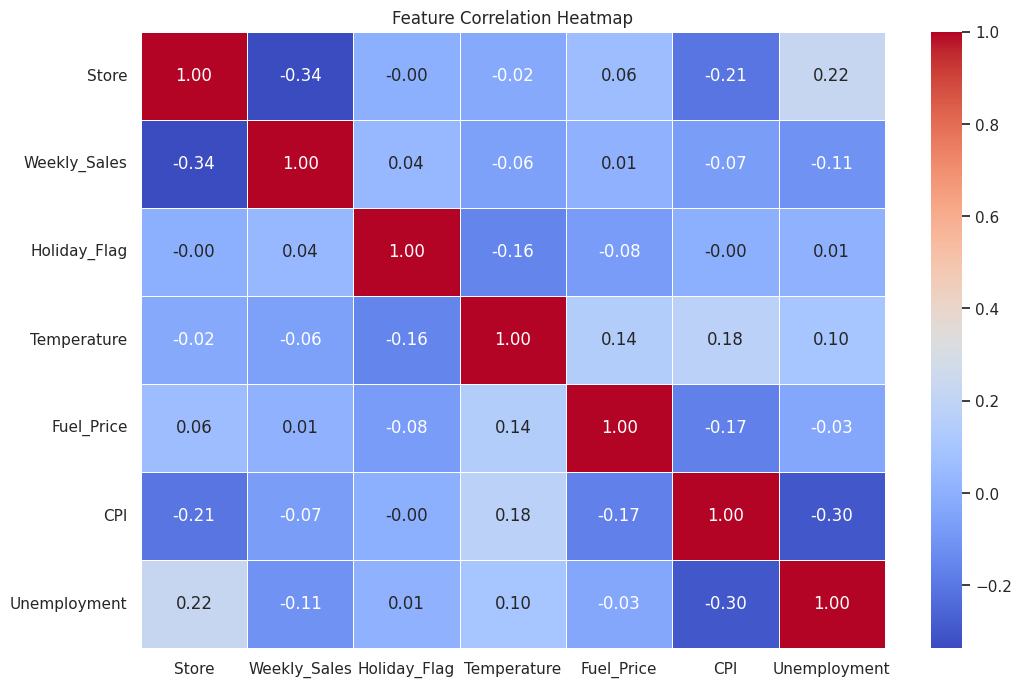

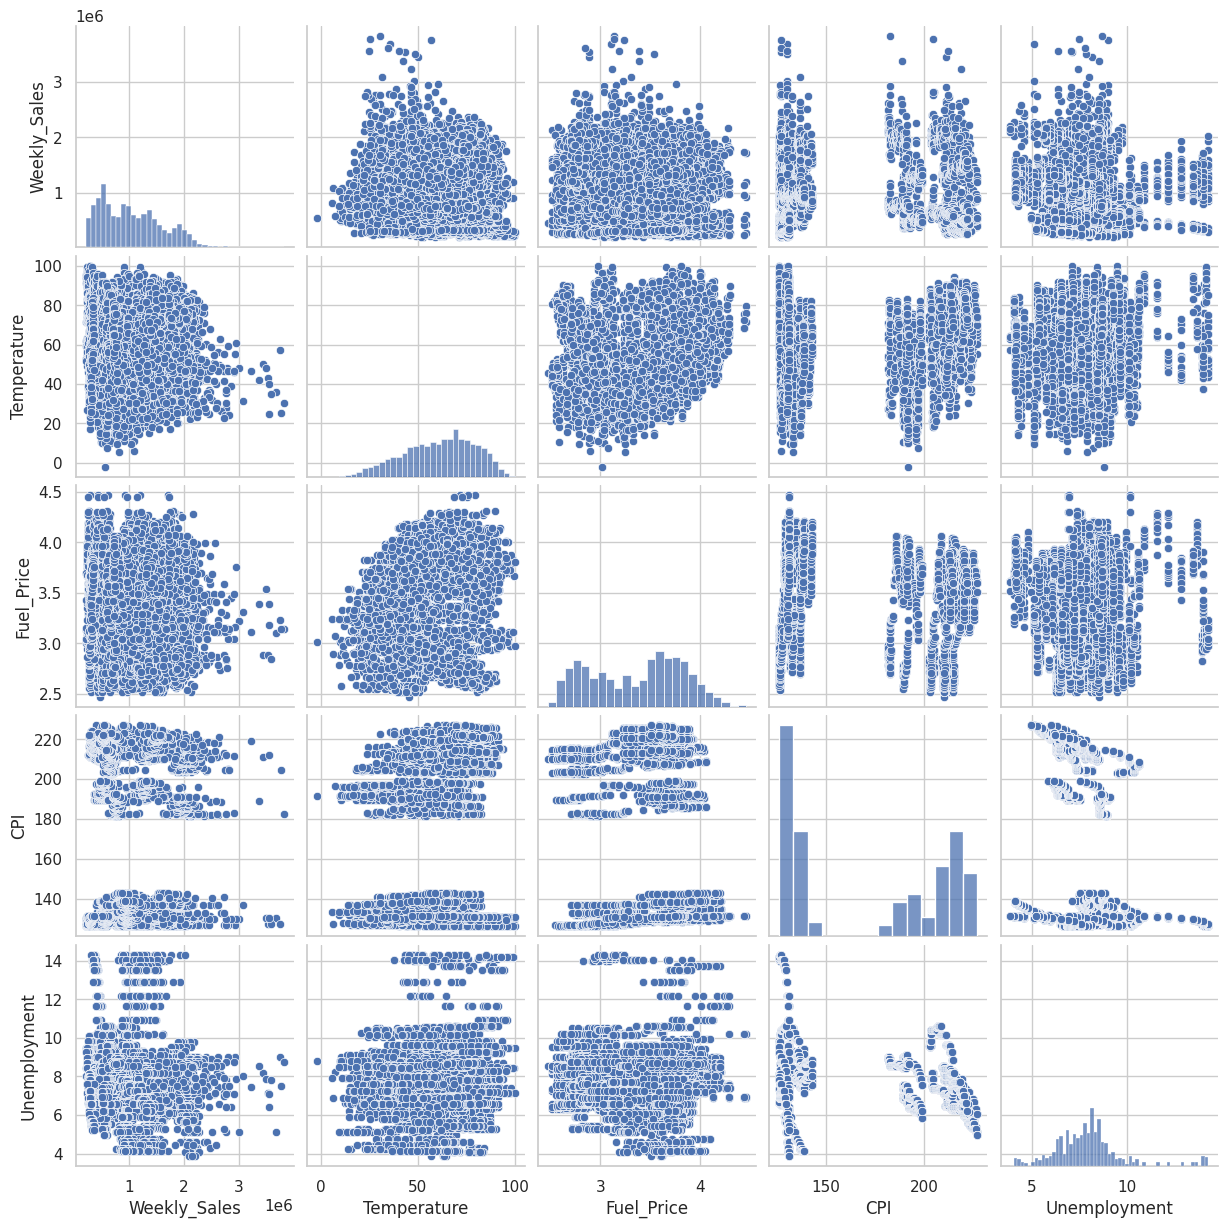

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import numpy as np

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")


print("Missing Values:\n", df.isnull().sum())


print("\nSummary Statistics:\n", df.describe())

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

# Correcting the pairplot to use existing columns
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
plt.show()

Text(0, 0.5, '')

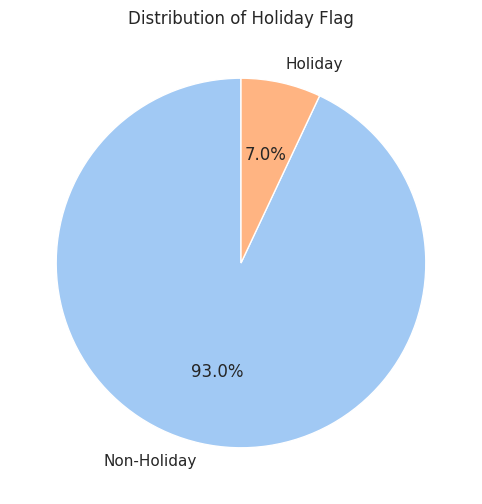

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.figure(figsize=(10,6))

holiday_counts = df['Holiday_Flag'].value_counts()
plt.pie(holiday_counts, labels=['Non-Holiday' if h == 0 else 'Holiday' for h in holiday_counts.index], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Holiday Flag')
plt.ylabel('') # Remove y-label for pie chart

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Unemployment", "Date"])  # Drop both target and non-numeric 'Date' column
y = df["Unemployment"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1662
RMSE: 1.7227


/tmp/ipykernel_668/1071636684.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x="Temperature",y="Weekly_Sales",palette='pastel')


Text(0, 0.5, 'Weekly_Sales')

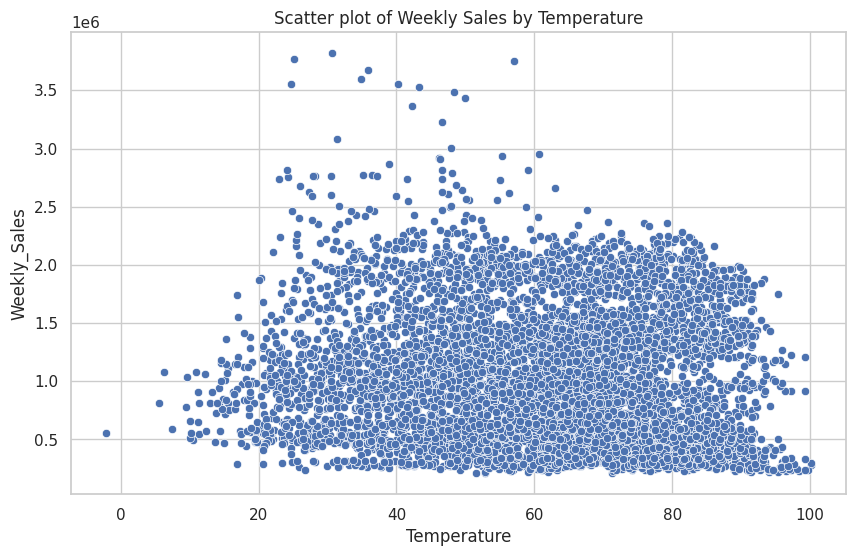

In [43]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Temperature",y="Weekly_Sales",palette='pastel')
plt.title('Scatter plot of Weekly Sales by Temperature')
plt.xlabel('Temperature',fontsize=12)
plt.ylabel('Weekly_Sales',fontsize=12)

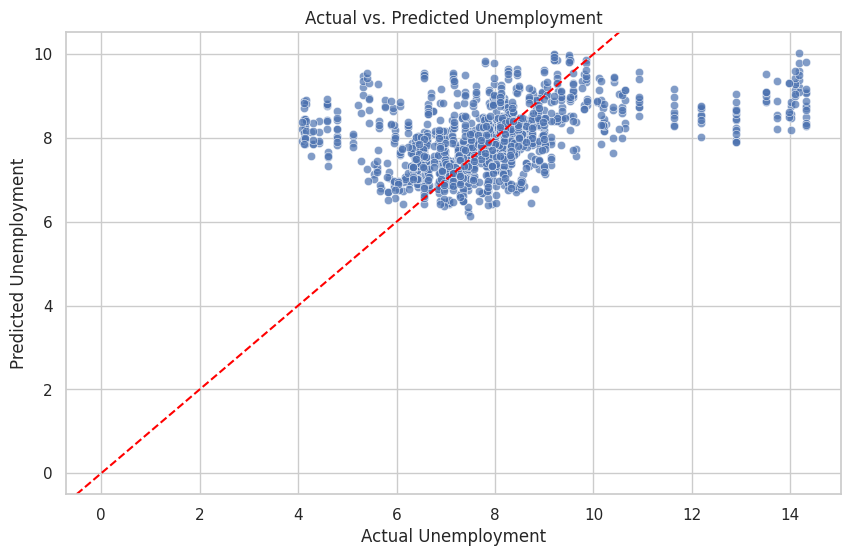

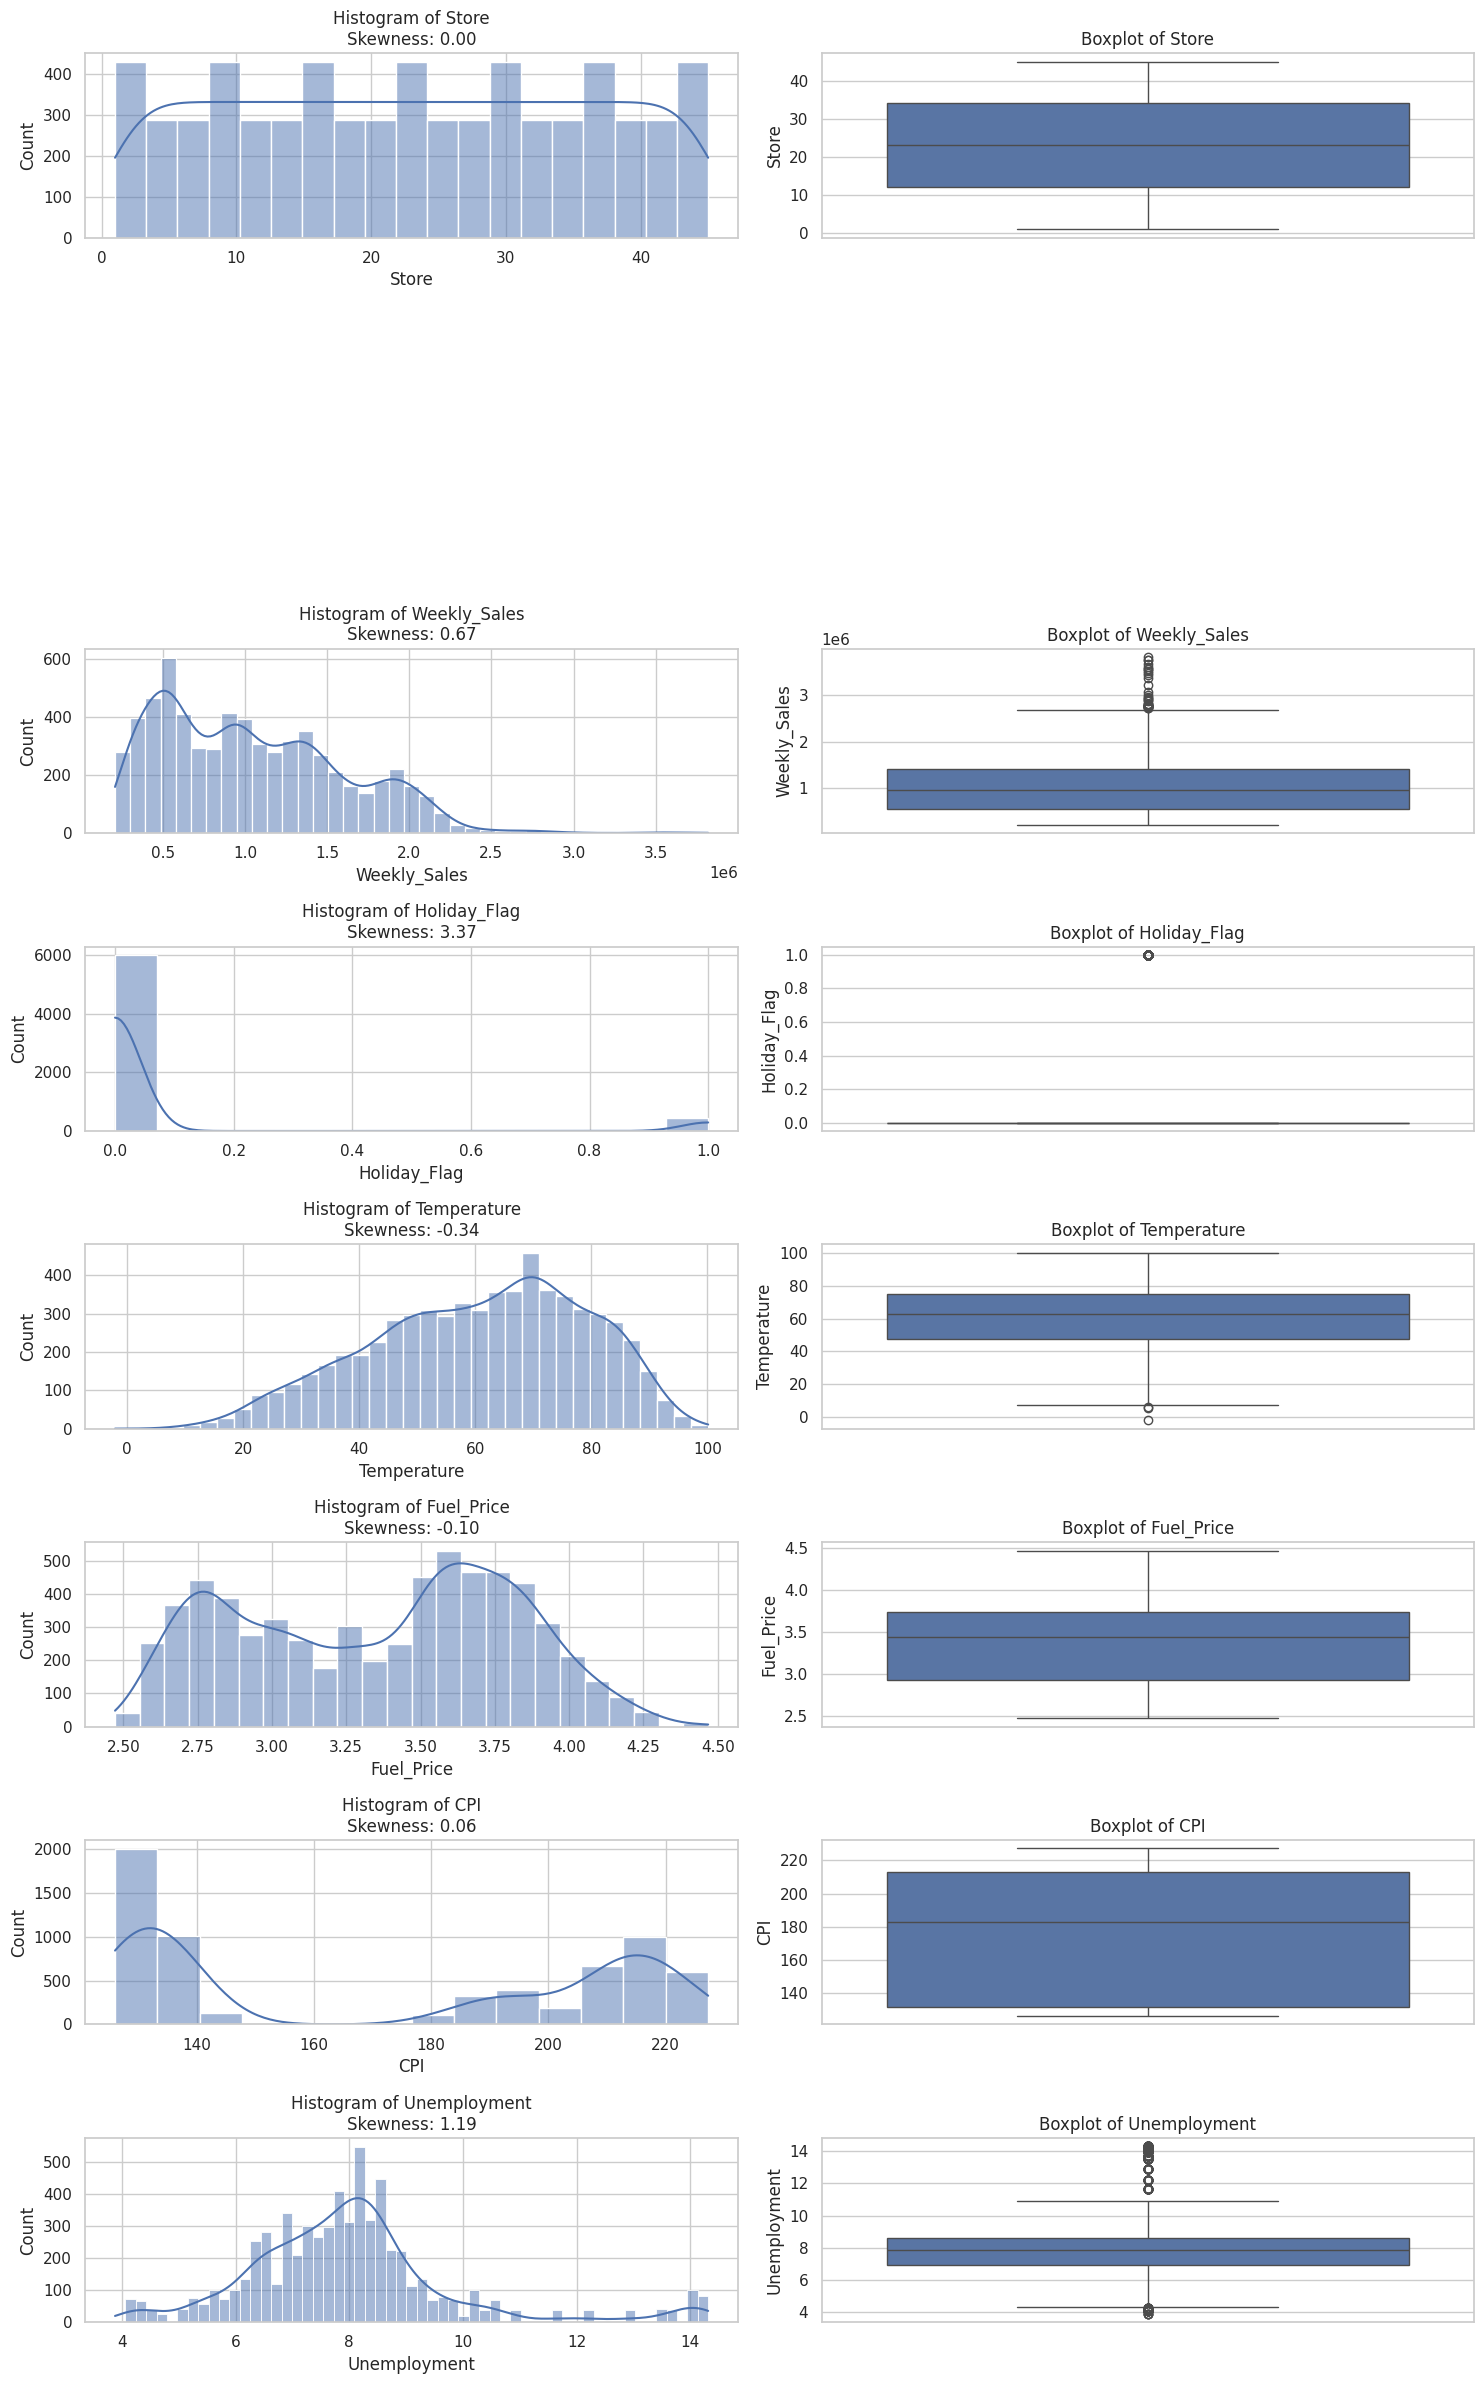

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Unemployment")
plt.ylabel("Predicted Unemployment")
plt.title("Actual vs. Predicted Unemployment")
plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()

# Calculate skewness only for numerical columns
skewness = df.select_dtypes(include=['number']).skew()

num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
  # Ensure to only plot numerical columns
  if df[col].dtype != 'object': # Exclude object type columns (like 'Date')
    plt.subplot(num_cols,2,2*i+1)
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}") # Use .get() for columns not in skewness

    plt.subplot(num_cols,2,2*i+2)
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [45]:
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df[['Day','Month','Year']]

,Day,Month,Year
0,5,2,2010
1,12,2,2010
2,19,2,2010
3,26,2,2010
4,5,3,2010
...,...,...,...
6430,28,9,2012
6431,5,10,2012
6432,12,10,2012
6433,19,10,2012


In [46]:
#find highly skewed cols
skewed_cols=df.select_dtypes(include=['number']).skew().abs()
highly_skewed = skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly skewed cols:")
print(highly_skewed)
print("negatively skewed cols:")
print(negatively_skewed)

Highly skewed cols:
Index(['Holiday_Flag', 'Unemployment'], dtype='object')
negatively skewed cols:
Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [47]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))
df[highly_skewed]

,Holiday_Flag,Unemployment
0,0.000000,2.208934
1,0.693147,2.208934
2,0.000000,2.208934
3,0.000000,2.208934
4,0.000000,2.208934
...,...,...
6430,0.000000,2.270475
6431,0.000000,2.268718
6432,0.000000,2.268718
6433,0.000000,2.268718


In [48]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])
df[negatively_skewed]

,Store,Weekly_Sales,Temperature,Fuel_Price,CPI,Year,Month,Day
0,-1.942666,1.062778,-1.017966,-1.683544,1.006528,-8.221201e-14,-1.429897,-1.239004
1,-1.942666,1.060635,-1.204376,-1.732738,1.009450,-8.221201e-14,-1.429897,-0.335247
2,-1.942666,1.023306,-1.135341,-1.802251,1.010391,-8.221201e-14,-1.429897,0.436415
3,-1.942666,0.757367,-0.799809,-1.706104,1.011002,-8.221201e-14,-1.429897,1.135378
4,-1.942666,0.950729,-0.806467,-1.574543,1.011613,-8.221201e-14,-1.059317,-1.239004
...,...,...,...,...,...,...,...,...
6430,1.554160,-0.454488,0.186582,1.408278,0.604228,8.809620e-14,0.801637,1.325422
6431,1.554160,-0.408915,0.187148,1.380942,0.607706,8.809620e-14,1.076394,-1.239004
6432,1.554160,-0.406671,-0.388228,1.415115,0.611181,8.809620e-14,1.076394,-0.335247
6433,1.554160,-0.443275,-0.280200,1.344527,0.611260,8.809620e-14,1.076394,0.436415


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Corrected to use 'Unemployment' as target and drop it, along with 'Date' if it's still in df
X = df.drop(columns=["Unemployment", "Date"])  # All columns except target and non-numeric 'Date'
y = df["Unemployment"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1390
RMSE: 0.1859


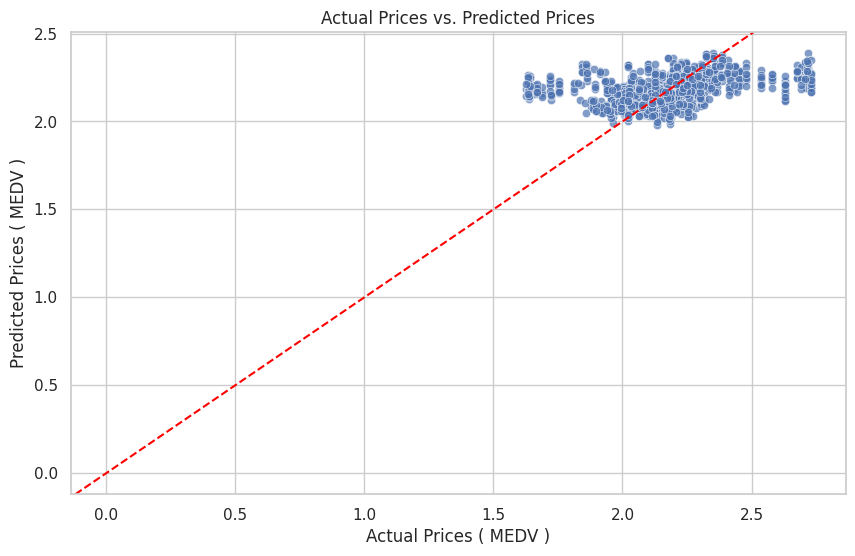

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

#scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices ( MEDV )")
plt.ylabel("Predicted Prices ( MEDV )")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0, 0], [1,1], color='red', linestyle='--')
plt.show()


In [51]:
from sklearn.ensemble import RandomForestRegressor

#train random forest
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#predictions
y_pred_rf=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred_rf)
rmse=mean_squared_error(y_test,y_pred_rf)**0.5

print(f"Random forest r2 score: {r2:.4f}")
print(f"Random forest RMSE: {rmse:.4f}")

Random forest r2 score: 0.9921
Random forest RMSE: 0.0178
